In [ ]:
%config InteractiveShell.ast_node_interactivity = "none"

# Run this cell first to set up the notebook!

!git clone -q https://github.com/jamcoders/syllabus-resources-2026.git

import sys
sys.path.append("/content/syllabus-resources-2026/week4/lecs")

# Language Modeling

In [2]:
from jamcoders.models import gpt2
prefix = "Good morning class!"
max_length = 20

In [3]:
generated = gpt2(prefix, 20)
print(generated)

Good morning class!‬♦I am just starting to enjoy the new game for you...


## What is a Model?

Yesterday we modeled the process of sampling Skittles from a cup 🍬

- A **model** is a simplified representation of something complex
- We use models when we can't fully understand or describe the real thing
- Models help us make predictions and understand patterns

> "All models are wrong, but some are useful" - George Box

In [4]:
# Yesterday's model: sampling from a cup
small_cup = ["red", "red", "red", "purple", "yellow", "green"]

In [5]:
from jamcoders.random import sample_from_list
skittle = sample_from_list(small_cup)
print(skittle)

red


This is a model of the shake-and-choose experiment (one iteration). In the actual experiment, we sampled 12 times and tallied the counts of what we saw. Let's code that up:

In [6]:
from jamcoders.random import sample_from_list
example_cup = ["red", "yellow", "yellow"]
print(sample_from_list(example_cup))

yellow


In [7]:
from jamcoders.random import sample_from_list
# Student's solution
def sample_twelve_times(cup):
    counts = {}
    for i in range(12):
        skittle = sample_from_list(cup)
        if skittle not in counts:
            counts[skittle] = 1
        else:
            counts[skittle] += 1
    return counts

print(sample_twelve_times(["red", "yellow"]))

{'red': 5, 'yellow': 7}


In [8]:
# Skittle 🆙
big_cup = ['purple', 'purple', 'purple', 'red', 'red', 'red', 'purple', 'red', 'red', 'green', 'yellow', 'green', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'purple', 'red', 'red', 'red', 'red', 'red', 'purple', 'green', 'yellow', 'red', 'yellow', 'green', 'purple', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'red', 'red', 'red', 'purple', 'red', 'red', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'green', 'green', 'red', 'red', 'purple', 'red', 'purple', 'red', 'purple', 'red', 'red', 'red', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'green', 'purple', 'red', 'purple', 'red', 'purple', 'red', 'purple', 'red', 'red', 'red', 'purple', 'red', 'red', 'purple', 'purple', 'red', 'red', 'green', 'green', 'red', 'red', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'green', 'purple', 'red', 'purple', 'green', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'purple', 'purple', 'red', 'yellow', 'red', 'green', 'red', 'yellow', 'green', 'red', 'yellow', 'purple', 'green', 'red', 'yellow', 'yellow', 'red', 'purple', 'green', 'purple', 'green', 'red', 'red', 'red', 'yellow', 'green', 'purple', 'green', 'red', 'red', 'red', 'red', 'green', 'yellow', 'red', 'red', 'purple', 'green', 'yellow', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'green', 'purple', 'purple', 'red', 'purple', 'yellow', 'red', 'red', 'purple', 'green', 'red', 'red', 'purple', 'red', 'red', 'purple', 'purple', 'purple', 'red', 'purple', 'green', 'yellow', 'purple', 'purple', 'purple', 'red', 'red', 'purple', 'red', 'red', 'green', 'red', 'yellow', 'yellow', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'purple', 'green', 'purple', 'red', 'red', 'purple', 'red', 'red', 'yellow', 'green', 'red', 'green', 'purple', 'red', 'green', 'green', 'green', 'purple', 'purple', 'red', 'red', 'red', 'yellow', 'yellow', 'red', 'green', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'purple', 'green', 'purple', 'red', 'red', 'green', 'yellow', 'purple', 'green', 'green', 'yellow', 'yellow', 'green', 'purple', 'purple', 'red', 'red', 'red', 'yellow', 'yellow', 'green', 'red', 'purple', 'green', 'purple', 'green', 'red', 'green', 'green', 'yellow', 'red', 'red', 'purple', 'red', 'green', 'purple', 'red', 'red', 'yellow', 'yellow', 'green', 'yellow', 'green', 'red', 'red', 'purple', 'red', 'red', 'green', 'yellow', 'red', 'purple', 'red', 'red', 'green', 'purple', 'purple', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'green', 'red', 'purple', 'yellow', 'red', 'yellow', 'red', 'yellow', 'purple', 'red', 'purple', 'purple', 'purple', 'red', 'red', 'green', 'yellow', 'green', 'purple', 'yellow', 'red', 'purple', 'yellow', 'red', 'yellow', 'red', 'yellow', 'yellow', 'red', 'purple', 'purple', 'red', 'yellow', 'yellow', 'green', 'red', 'green', 'yellow', 'yellow', 'red', 'yellow', 'purple', 'red', 'green', 'green', 'red', 'red', 'purple', 'green', 'red', 'purple', 'red', 'green', 'green', 'red', 'red', 'yellow', 'red', 'red', 'purple', 'red', 'yellow', 'green', 'red', 'red', 'red', 'red', 'yellow', 'yellow', 'yellow', 'yellow', 'green', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'purple', 'yellow', 'red', 'green', 'red', 'red', 'purple', 'yellow', 'green', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'green', 'red', 'red', 'red', 'yellow', 'green', 'red', 'red', 'red', 'red', 'yellow', 'green', 'red', 'yellow', 'red', 'red', 'yellow', 'green', 'purple', 'red', 'red', 'green', 'red', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'yellow', 'yellow', 'red', 'green', 'red', 'yellow', 'purple', 'purple', 'yellow', 'yellow', 'red', 'red', 'purple', 'red', 'red', 'yellow', 'purple', 'red', 'red', 'purple', 'green', 'green', 'red', 'red', 'red', 'green', 'red', 'green', 'red', 'green', 'red', 'purple', 'green', 'yellow', 'purple', 'red', 'red', 'purple', 'red', 'purple', 'red', 'red', 'purple', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'green', 'red', 'yellow', 'purple', 'red', 'purple', 'yellow', 'yellow', 'red', 'purple', 'red', 'yellow', 'red', 'yellow', 'red', 'purple', 'purple', 'red', 'red', 'red', 'red', 'purple', 'purple', 'purple', 'red', 'red', 'red', 'yellow', 'yellow', 'yellow', 'red', 'yellow', 'purple', 'purple', 'red', 'red', 'yellow', 'green', 'red', 'green', 'yellow', 'red', 'red', 'red', 'red', 'red', 'yellow', 'yellow', 'green', 'red', 'purple', 'red', 'red', 'yellow', 'purple', 'green', 'green', 'yellow', 'yellow', 'yellow', 'red', 'yellow', 'yellow', 'purple', 'red', 'red', 'red', 'green', 'green', 'green', 'red', 'green', 'red', 'red', 'yellow', 'green', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'green', 'red', 'yellow', 'green', 'green', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'purple', 'purple', 'green', 'purple', 'red', 'red', 'purple', 'purple', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'green', 'purple', 'red', 'green', 'red', 'purple', 'green', 'purple', 'green', 'purple', 'red', 'red', 'green', 'red', 'red', 'yellow', 'yellow', 'green', 'red', 'green', 'red', 'purple', 'red', 'red', 'yellow', 'purple', 'red', 'purple', 'red', 'red', 'red', 'red', 'purple', 'red', 'purple', 'yellow', 'purple', 'purple', 'red', 'purple', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'purple', 'red', 'green', 'red', 'red', 'purple', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'yellow', 'purple', 'purple', 'purple', 'red', 'red', 'red', 'purple', 'green', 'yellow', 'purple', 'red', 'green', 'purple', 'green', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'red', 'green', 'yellow', 'red', 'red', 'purple', 'red', 'purple', 'purple', 'yellow', 'green', 'yellow', 'red', 'green', 'red', 'red', 'red', 'yellow', 'purple', 'red', 'green', 'red', 'purple', 'purple', 'yellow', 'red', 'purple', 'green', 'green', 'purple', 'yellow', 'red', 'green', 'purple', 'red', 'yellow', 'green', 'red', 'yellow', 'red', 'purple', 'yellow', 'purple', 'red', 'red', 'red', 'purple', 'yellow', 'yellow', 'red', 'green', 'red', 'purple', 'red', 'green', 'green', 'red', 'red', 'yellow', 'red', 'yellow', 'green', 'yellow', 'red', 'red', 'yellow', 'purple', 'red', 'green', 'red', 'yellow', 'purple', 'purple', 'red', 'green', 'yellow', 'green', 'red', 'purple', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'yellow', 'yellow', 'green', 'purple', 'purple', 'yellow', 'green', 'purple', 'red', 'red', 'yellow', 'yellow', 'yellow', 'yellow', 'purple', 'purple', 'purple', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'red', 'red', 'green', 'red', 'red', 'red', 'purple', 'purple', 'red', 'green', 'purple', 'purple', 'red', 'green', 'red', 'green', 'green', 'yellow', 'yellow', 'red', 'green', 'green', 'yellow', 'purple', 'purple', 'green', 'purple', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'purple', 'red', 'green', 'green', 'green', 'red', 'red', 'yellow', 'green', 'red', 'yellow', 'red', 'red', 'red', 'green', 'yellow', 'yellow', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'purple', 'yellow', 'yellow', 'purple', 'purple', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'green', 'purple', 'green', 'yellow', 'red', 'red', 'red', 'purple', 'green', 'green', 'yellow', 'red', 'red', 'yellow', 'purple', 'red', 'red', 'yellow', 'yellow', 'red', 'purple', 'red', 'red', 'red', 'red', 'green', 'red', 'yellow', 'red', 'green', 'red', 'red', 'yellow', 'yellow', 'yellow', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'red', 'green', 'green', 'purple', 'yellow', 'red', 'red', 'yellow', 'red', 'red', 'red', 'green', 'green', 'purple', 'red', 'purple', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'purple', 'green', 'red', 'green', 'red', 'red', 'purple', 'purple', 'red', 'purple', 'yellow', 'green', 'green', 'red', 'red', 'purple', 'red', 'green', 'green', 'red', 'red', 'red', 'yellow', 'purple', 'purple', 'green', 'red', 'purple', 'green', 'green', 'red', 'purple', 'purple', 'red', 'red', 'red', 'green', 'purple', 'purple', 'red', 'green', 'green', 'red', 'red', 'yellow', 'red', 'green', 'purple', 'red', 'red', 'purple', 'red', 'yellow', 'purple', 'purple', 'yellow', 'green', 'green', 'red', 'red', 'red', 'red', 'purple', 'red', 'red', 'yellow', 'green', 'green', 'red', 'green', 'yellow', 'purple', 'red', 'purple', 'purple', 'green', 'green', 'red', 'red', 'red', 'yellow', 'green', 'green', 'red', 'red', 'red', 'purple', 'yellow', 'purple', 'yellow', 'purple', 'red', 'yellow', 'yellow', 'green', 'red', 'red', 'green', 'red', 'yellow', 'green', 'purple', 'yellow', 'yellow', 'red', 'yellow', 'purple', 'red', 'red', 'yellow', 'green', 'red', 'green', 'red', 'yellow', 'purple', 'red', 'red', 'yellow', 'purple', 'purple', 'red', 'red', 'purple', 'purple', 'red', 'yellow', 'purple', 'purple', 'purple', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'yellow', 'yellow', 'purple', 'red', 'red', 'red', 'purple', 'green', 'yellow', 'green', 'red', 'yellow', 'purple', 'red', 'purple', 'red', 'yellow', 'red', 'green', 'purple', 'yellow', 'purple', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'purple', 'red', 'green', 'red', 'purple', 'yellow', 'purple', 'red', 'red', 'purple', 'purple', 'red', 'yellow', 'yellow', 'purple', 'red', 'yellow', 'yellow', 'green', 'red', 'purple', 'red', 'red', 'green', 'red', 'green', 'yellow', 'red', 'green', 'green', 'yellow', 'yellow', 'purple', 'red', 'purple', 'purple', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'red', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'purple', 'red', 'purple', 'red', 'red', 'red', 'red', 'yellow', 'green', 'yellow', 'purple', 'yellow', 'purple', 'purple', 'red', 'red', 'purple', 'green', 'purple', 'red', 'yellow', 'green', 'red', 'green', 'red', 'red', 'red', 'purple', 'red', 'purple', 'green', 'red', 'red', 'purple', 'yellow', 'red', 'yellow', 'purple', 'green', 'red', 'red', 'green', 'green', 'green', 'red', 'green', 'red', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'red', 'yellow', 'yellow', 'yellow', 'red', 'red', 'purple', 'red', 'green', 'purple', 'purple', 'red', 'red', 'yellow', 'red', 'green', 'purple', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'red', 'purple', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'yellow', 'red', 'red', 'red', 'yellow', 'purple', 'purple', 'yellow', 'red', 'yellow', 'green', 'red', 'red', 'yellow', 'yellow', 'red', 'red', 'purple', 'red', 'red', 'red', 'red', 'purple', 'purple', 'green', 'yellow', 'green', 'red', 'green', 'red', 'red', 'red', 'red', 'yellow', 'purple', 'red', 'green', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'yellow', 'yellow', 'red', 'yellow', 'green', 'purple', 'purple', 'red', 'red', 'purple', 'red', 'red', 'purple', 'yellow', 'yellow', 'red', 'purple', 'yellow', 'yellow', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'purple', 'purple', 'purple', 'red', 'green', 'red', 'red', 'yellow', 'red', 'green', 'red', 'yellow', 'green', 'yellow', 'red', 'green', 'red', 'yellow', 'green', 'green', 'purple', 'green', 'green', 'purple', 'yellow', 'red', 'red', 'yellow', 'yellow', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'red', 'yellow', 'purple', 'red', 'green', 'red', 'green', 'red', 'red', 'red', 'purple', 'red', 'green', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'purple', 'red', 'green', 'red', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'yellow', 'green', 'green', 'yellow', 'yellow', 'green', 'red', 'purple', 'green', 'yellow', 'red', 'purple', 'green', 'purple', 'red', 'green', 'green', 'red', 'yellow', 'red', 'green', 'red', 'purple', 'yellow', 'red', 'yellow', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'purple', 'purple', 'yellow', 'yellow', 'purple', 'yellow', 'red', 'green', 'green', 'yellow', 'red', 'yellow', 'red', 'green', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'purple', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'green', 'red', 'red', 'red', 'purple', 'red', 'red', 'red', 'green', 'purple', 'red', 'green', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'green', 'yellow', 'green', 'red', 'red', 'red', 'red', 'purple', 'green', 'green', 'green', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'green', 'yellow', 'red', 'purple', 'yellow', 'red', 'red', 'yellow', 'green', 'yellow', 'red', 'red', 'yellow', 'green', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'green', 'yellow', 'purple', 'red', 'red', 'yellow', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'red', 'red', 'red', 'green', 'red', 'red', 'purple', 'red', 'yellow', 'red', 'red', 'red', 'red', 'green', 'purple', 'red', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'red', 'green', 'green', 'purple', 'red', 'red', 'yellow', 'red', 'green', 'red', 'red', 'red', 'green', 'purple', 'red', 'red', 'green', 'purple', 'purple', 'purple', 'purple', 'purple', 'red', 'red', 'green', 'yellow', 'purple', 'purple', 'purple', 'red', 'purple', 'red', 'red', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'red', 'red', 'yellow', 'purple', 'purple', 'red', 'yellow', 'red', 'purple', 'purple', 'red', 'purple', 'purple', 'red', 'red', 'purple', 'red', 'green', 'yellow', 'purple', 'green', 'red', 'red', 'yellow', 'red', 'purple', 'yellow', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'green', 'red', 'red', 'purple', 'purple', 'red', 'green', 'yellow', 'red', 'red', 'purple', 'red', 'red', 'purple', 'purple', 'purple', 'purple', 'purple', 'yellow', 'red', 'red', 'red', 'green', 'green', 'purple', 'green', 'red', 'red', 'yellow', 'red', 'red', 'yellow', 'red', 'green', 'purple', 'green', 'red', 'red', 'red', 'purple', 'red', 'purple', 'purple', 'red', 'red', 'purple', 'red', 'purple', 'red', 'yellow', 'purple', 'purple', 'red', 'red', 'red', 'red', 'red', 'yellow', 'purple', 'green', 'purple', 'red', 'green', 'green', 'red', 'red', 'green', 'purple', 'red', 'yellow', 'red', 'red', 'purple', 'red', 'red', 'yellow', 'red', 'purple', 'purple', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'red', 'yellow', 'green', 'red', 'red', 'yellow', 'red', 'green', 'green', 'purple', 'red', 'purple', 'red', 'red', 'yellow', 'red', 'green', 'yellow', 'green', 'purple', 'red', 'green', 'green', 'red', 'yellow', 'yellow', 'purple', 'green', 'green', 'purple', 'red', 'yellow', 'yellow', 'yellow', 'red', 'red', 'red', 'yellow', 'purple', 'red', 'red', 'green', 'red', 'purple', 'purple', 'yellow', 'red', 'red', 'red', 'yellow', 'yellow', 'purple', 'yellow', 'red', 'yellow', 'yellow', 'green', 'yellow', 'purple', 'red', 'green', 'red', 'red', 'yellow', 'purple', 'green', 'yellow', 'green', 'red', 'red', 'green', 'yellow', 'green', 'green', 'purple', 'purple', 'red', 'red', 'purple', 'red', 'purple', 'red', 'green', 'purple', 'red', 'red', 'green', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'yellow', 'yellow', 'yellow', 'red', 'green', 'green', 'red', 'yellow', 'red', 'red', 'red', 'green', 'purple', 'red', 'yellow', 'red', 'purple', 'red', 'purple', 'purple', 'green', 'red', 'purple', 'red', 'green', 'yellow', 'green', 'green', 'red', 'green', 'red', 'red', 'yellow', 'red', 'purple', 'purple', 'red', 'red', 'red', 'green', 'green', 'red', 'red', 'red', 'purple', 'green', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'purple', 'green', 'red', 'red', 'red', 'yellow', 'purple', 'yellow', 'red', 'red', 'red', 'red', 'red', 'yellow', 'purple', 'yellow', 'red', 'red', 'purple', 'purple', 'red', 'green', 'green', 'red', 'purple', 'red', 'red', 'yellow', 'red', 'yellow', 'green', 'yellow', 'red', 'green', 'green', 'purple', 'green', 'red', 'red', 'red', 'red', 'purple', 'red', 'green', 'green', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'green', 'red', 'red', 'purple', 'red', 'red', 'purple', 'green', 'red', 'red', 'red', 'purple', 'red', 'green', 'red', 'red', 'purple', 'red', 'red', 'purple', 'purple', 'yellow', 'red', 'red', 'green', 'red', 'purple', 'purple', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'yellow', 'red', 'yellow', 'red', 'red', 'green', 'yellow', 'purple', 'red', 'red', 'red', 'purple', 'purple', 'red', 'red', 'red', 'red', 'red', 'purple', 'yellow', 'yellow', 'green', 'red', 'green', 'red', 'red', 'purple', 'red', 'green', 'green', 'purple', 'yellow', 'red', 'red', 'purple', 'yellow', 'yellow', 'green', 'green', 'red', 'red', 'green', 'red', 'red', 'yellow', 'red', 'red', 'purple', 'red', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'yellow', 'yellow', 'red', 'purple', 'purple', 'yellow', 'red', 'red', 'yellow', 'yellow', 'green', 'green', 'purple', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'red', 'red', 'yellow', 'purple', 'yellow', 'purple', 'green', 'green', 'purple', 'yellow', 'purple', 'red', 'red', 'green', 'red', 'green', 'green', 'red', 'red', 'purple', 'red', 'purple', 'purple', 'red', 'green', 'red', 'red', 'red', 'red', 'purple', 'red', 'green', 'green', 'red', 'yellow', 'yellow', 'red', 'purple', 'green', 'red', 'purple', 'red', 'red', 'red', 'yellow', 'red', 'purple', 'yellow', 'purple', 'green', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'yellow', 'green', 'green', 'green', 'red', 'green', 'red', 'red', 'red', 'green', 'purple', 'red', 'red', 'purple', 'red', 'green', 'purple', 'purple', 'green', 'red', 'purple', 'purple', 'red', 'purple', 'purple', 'yellow', 'red', 'yellow', 'red', 'green', 'yellow', 'red', 'red', 'green', 'red', 'red', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'purple', 'yellow', 'green', 'yellow', 'green', 'yellow', 'red', 'purple', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'yellow', 'green', 'red', 'purple', 'red', 'purple', 'green', 'green', 'yellow', 'red', 'red', 'red', 'yellow', 'purple', 'red', 'red', 'yellow', 'green', 'red', 'red', 'purple', 'red', 'green', 'red', 'red', 'purple', 'green', 'red', 'purple', 'red', 'green', 'red', 'red', 'red', 'yellow', 'yellow', 'yellow', 'purple', 'red', 'red', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'red', 'red', 'red', 'red', 'yellow', 'yellow', 'purple', 'red', 'purple', 'red', 'red', 'purple', 'green', 'green', 'red', 'red', 'red', 'green', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'green', 'green', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'yellow', 'red', 'yellow', 'yellow', 'red', 'red', 'yellow', 'purple', 'red', 'yellow', 'yellow', 'yellow', 'purple', 'yellow', 'red', 'red', 'red', 'red', 'purple', 'green', 'red', 'red', 'purple', 'green', 'red', 'purple', 'purple', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'yellow', 'yellow', 'red', 'yellow', 'purple', 'red', 'purple', 'yellow', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'purple', 'yellow', 'red', 'purple', 'red', 'purple', 'yellow', 'purple', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'green', 'red', 'red', 'red', 'green', 'red', 'purple', 'red', 'red', 'green', 'green', 'purple', 'yellow', 'red', 'green', 'red', 'red', 'red', 'red', 'green', 'purple', 'purple', 'red', 'red', 'red', 'red', 'green', 'red', 'yellow', 'red', 'yellow', 'yellow', 'red', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'red', 'green', 'red', 'purple', 'green', 'yellow', 'yellow', 'green', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'purple', 'green', 'green', 'green', 'purple', 'red', 'purple', 'purple', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'green', 'red', 'red', 'yellow', 'red', 'green', 'green', 'purple', 'red', 'yellow', 'red', 'red', 'red', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'yellow', 'green', 'purple', 'purple', 'purple', 'green', 'yellow', 'red', 'green', 'green', 'purple', 'red', 'purple', 'yellow', 'purple', 'yellow', 'green', 'yellow', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'purple', 'yellow', 'red', 'red', 'red', 'green', 'red', 'green', 'red', 'purple', 'purple', 'red', 'yellow', 'red', 'green', 'red', 'green', 'green', 'red', 'green', 'red', 'yellow', 'yellow', 'red', 'green', 'purple', 'green', 'red', 'yellow', 'purple', 'red', 'red', 'red', 'red', 'yellow', 'red', 'purple', 'purple', 'red', 'red', 'red', 'red', 'yellow', 'yellow', 'red', 'red', 'red', 'red', 'purple', 'red', 'purple', 'green', 'red', 'purple', 'green', 'purple', 'yellow', 'red', 'red', 'purple', 'yellow', 'red', 'yellow', 'purple', 'red', 'red', 'red', 'yellow', 'yellow', 'red', 'red', 'red', 'purple', 'green', 'green', 'yellow', 'red', 'yellow', 'purple', 'purple', 'red', 'purple', 'purple', 'purple', 'red', 'red', 'yellow', 'green', 'yellow', 'yellow', 'red', 'green', 'red', 'yellow', 'green', 'yellow', 'yellow', 'red', 'yellow', 'green', 'red', 'yellow', 'yellow', 'purple', 'red', 'green', 'purple', 'yellow', 'red', 'green', 'purple', 'yellow', 'red', 'yellow', 'green', 'red', 'yellow', 'green', 'red', 'red', 'green', 'red', 'yellow', 'purple', 'green', 'red', 'red', 'purple', 'red', 'purple', 'green', 'purple', 'yellow', 'red', 'red', 'red', 'red', 'purple', 'red', 'purple', 'red', 'red', 'purple', 'red', 'yellow', 'green', 'red', 'green', 'purple', 'red', 'red', 'green', 'purple', 'yellow', 'red', 'green', 'red', 'yellow', 'purple', 'red', 'red', 'green', 'red', 'green', 'yellow', 'purple', 'red', 'green', 'red', 'green', 'yellow', 'red', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'yellow', 'purple', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'green', 'green', 'red', 'purple', 'green', 'red', 'yellow', 'red', 'yellow', 'yellow', 'yellow', 'red', 'red', 'yellow', 'red', 'purple', 'purple', 'red', 'red', 'red', 'green', 'purple', 'purple', 'red', 'red', 'green', 'purple', 'red', 'red', 'yellow', 'purple', 'red', 'red', 'red', 'green', 'red', 'yellow', 'purple', 'purple', 'red', 'red', 'red', 'green', 'red', 'yellow', 'purple', 'yellow', 'purple', 'red', 'red', 'purple', 'green', 'red', 'red', 'purple', 'red', 'purple', 'green', 'purple', 'purple', 'red', 'red', 'red', 'red', 'red', 'purple', 'red', 'green', 'red', 'purple', 'red', 'red', 'green', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'purple', 'red', 'red', 'green', 'yellow', 'purple', 'red', 'red', 'purple', 'green', 'green', 'purple', 'purple', 'yellow', 'yellow', 'red', 'red', 'red', 'green', 'purple', 'green', 'red', 'green', 'yellow', 'green', 'red', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'yellow', 'yellow', 'red', 'red', 'red', 'red', 'green', 'purple', 'red', 'red', 'purple', 'red', 'purple', 'red', 'purple', 'red', 'red', 'red', 'green', 'red', 'yellow', 'red', 'purple', 'green', 'green', 'purple', 'green', 'red', 'green', 'yellow', 'green', 'red', 'green', 'green', 'red', 'purple', 'red', 'green', 'green', 'red', 'green', 'red', 'yellow', 'yellow', 'red', 'green', 'red', 'red', 'purple', 'yellow', 'green', 'green', 'red', 'yellow', 'red', 'red', 'yellow', 'red', 'green', 'red', 'red', 'yellow', 'red', 'green', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'purple', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'purple', 'yellow', 'purple', 'green', 'red', 'purple', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'yellow', 'red', 'red', 'yellow', 'red', 'green', 'red', 'red', 'green', 'red', 'yellow', 'green', 'red', 'green', 'green', 'green', 'red', 'purple', 'green', 'yellow', 'yellow', 'purple', 'yellow', 'red', 'green', 'purple', 'purple', 'green', 'red', 'red', 'red', 'purple', 'yellow', 'red', 'purple', 'purple', 'yellow', 'red', 'yellow', 'red', 'green', 'green', 'red', 'red', 'purple', 'green', 'red', 'red', 'purple', 'purple', 'green', 'purple', 'purple', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'yellow', 'green', 'yellow', 'red', 'purple', 'red', 'red', 'red', 'purple', 'red', 'green', 'red', 'yellow', 'red', 'red', 'purple', 'red', 'yellow', 'yellow', 'red', 'red', 'red', 'purple', 'purple', 'green', 'red', 'red', 'yellow', 'red', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'red', 'green', 'purple', 'purple', 'purple', 'purple', 'red', 'red', 'green', 'green', 'purple', 'red', 'yellow', 'red', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'yellow', 'red', 'red', 'yellow', 'green', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'red', 'red', 'red', 'red', 'yellow', 'green', 'red', 'purple', 'green', 'purple', 'red', 'purple', 'red', 'red', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'red', 'purple', 'green', 'yellow', 'red', 'red', 'red', 'green', 'purple', 'purple', 'green', 'green', 'red', 'red', 'yellow', 'yellow', 'green', 'green', 'yellow', 'green', 'red', 'purple', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'red', 'yellow', 'green', 'yellow', 'red', 'red', 'red', 'green', 'green', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'yellow', 'red', 'red', 'red', 'green', 'green', 'red', 'red', 'yellow', 'red', 'red', 'yellow', 'yellow', 'yellow', 'yellow', 'purple', 'yellow', 'red', 'green', 'green', 'red', 'purple', 'green', 'yellow', 'red', 'yellow', 'red', 'green', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'green', 'red', 'red', 'green', 'purple', 'red', 'purple', 'purple', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'red', 'green', 'purple', 'red', 'red', 'green', 'red', 'purple', 'yellow', 'purple', 'yellow', 'purple', 'red', 'red', 'red', 'green', 'red', 'green', 'green', 'yellow', 'yellow', 'red', 'green', 'green', 'red', 'red', 'red', 'purple', 'red', 'red', 'red', 'green', 'green', 'red', 'red', 'green', 'red', 'purple', 'red', 'purple', 'red', 'purple', 'purple', 'red', 'red', 'yellow', 'yellow', 'purple', 'red', 'purple', 'yellow', 'purple', 'red', 'yellow', 'red', 'green', 'red', 'green', 'red', 'green', 'red', 'purple', 'green', 'red', 'red', 'red', 'yellow', 'yellow', 'purple', 'red', 'purple', 'yellow', 'green', 'green', 'red', 'red', 'red', 'red', 'purple', 'red', 'green', 'red', 'red', 'red', 'red', 'green', 'red', 'green', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'green', 'green', 'green', 'red', 'purple', 'green', 'red', 'yellow', 'green', 'red', 'red', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'purple', 'green', 'red', 'red', 'purple', 'red', 'green', 'yellow', 'red', 'green', 'green', 'green', 'red', 'purple', 'red', 'red', 'purple', 'red', 'yellow', 'red', 'red', 'green', 'red', 'purple', 'red', 'red', 'red', 'yellow', 'green', 'yellow', 'red', 'purple', 'green', 'purple', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'yellow', 'red', 'red', 'green', 'purple', 'red', 'red', 'yellow', 'green', 'yellow', 'green', 'green', 'red', 'green', 'green', 'red', 'red', 'red', 'green', 'red', 'yellow', 'green', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'yellow', 'purple', 'red', 'yellow', 'yellow', 'yellow', 'green', 'red', 'purple', 'red', 'green', 'green', 'red', 'red', 'red', 'purple', 'red', 'purple', 'red', 'yellow', 'red', 'green', 'green', 'green', 'green', 'purple', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'yellow', 'red', 'green', 'red', 'red', 'yellow', 'red', 'red', 'green', 'green', 'purple', 'purple', 'red', 'red', 'yellow', 'yellow', 'red', 'red', 'purple', 'green', 'yellow', 'red', 'green', 'red', 'green', 'green', 'red', 'purple', 'yellow', 'red', 'green', 'red', 'red', 'purple', 'red', 'yellow', 'purple', 'purple', 'red', 'red', 'green', 'red', 'purple', 'red', 'green', 'purple', 'red', 'green', 'red', 'red', 'red', 'purple', 'red', 'red', 'purple', 'purple', 'purple', 'red', 'green', 'red', 'purple', 'red', 'green', 'red', 'red', 'yellow', 'green', 'green', 'yellow', 'red', 'purple', 'red', 'red', 'yellow', 'purple', 'purple', 'green', 'purple', 'purple', 'yellow', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'purple', 'red', 'red', 'red', 'purple', 'green', 'red', 'purple', 'yellow', 'red', 'red', 'yellow', 'red', 'green', 'green', 'green', 'red', 'yellow', 'green', 'red', 'purple', 'purple', 'red', 'red', 'green', 'red', 'yellow', 'red', 'yellow', 'purple', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'purple', 'green', 'red', 'purple', 'purple', 'purple', 'purple', 'red', 'yellow', 'red', 'red', 'purple', 'red', 'red', 'green', 'red', 'yellow', 'green', 'purple', 'yellow', 'red', 'red', 'purple', 'red', 'green', 'green', 'red', 'green', 'purple', 'green', 'yellow', 'red', 'yellow', 'red', 'red', 'green', 'red', 'purple', 'green', 'red', 'red', 'purple', 'green', 'yellow', 'red', 'yellow', 'red', 'yellow', 'yellow', 'green', 'red', 'purple', 'yellow', 'yellow', 'yellow', 'red', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'yellow', 'red', 'purple', 'purple', 'yellow', 'red', 'yellow', 'yellow', 'red', 'red', 'red', 'green', 'purple', 'red', 'purple', 'red', 'red', 'yellow', 'red', 'yellow', 'green', 'yellow', 'yellow', 'yellow', 'red', 'red', 'green', 'purple', 'red', 'yellow', 'red', 'yellow', 'green', 'red', 'red', 'yellow', 'purple', 'green', 'red', 'red', 'red', 'purple', 'red', 'red', 'red', 'green', 'green', 'red', 'green', 'green', 'red', 'red', 'red', 'yellow', 'purple', 'red', 'green', 'red', 'red', 'green', 'purple', 'purple', 'red', 'red', 'green', 'green', 'red', 'green', 'red', 'red', 'purple', 'purple', 'yellow', 'green', 'purple', 'purple', 'red', 'red', 'red', 'yellow', 'yellow', 'yellow', 'green', 'red', 'red', 'purple', 'purple', 'red', 'purple', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'green', 'purple', 'green', 'red', 'yellow', 'purple', 'green', 'yellow', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'green', 'red', 'green', 'red', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'red', 'yellow', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'red', 'green', 'red', 'purple', 'yellow', 'red', 'green', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'purple', 'red', 'green', 'purple', 'red', 'green', 'yellow', 'green', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'purple', 'yellow', 'yellow', 'green', 'purple', 'red', 'red', 'green', 'red', 'red', 'purple', 'green', 'yellow', 'green', 'red', 'yellow', 'green', 'yellow', 'red', 'purple', 'purple', 'red', 'red', 'red', 'green', 'green', 'purple', 'red', 'green', 'green', 'yellow', 'purple', 'red', 'purple', 'red', 'red', 'red', 'red', 'green', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'purple', 'purple', 'red', 'red', 'red', 'red', 'purple', 'red', 'purple', 'red', 'red', 'purple', 'red', 'purple', 'green', 'red', 'yellow', 'green', 'yellow', 'red', 'red', 'red', 'red', 'purple', 'green', 'red', 'red', 'red', 'green', 'yellow', 'red', 'red', 'red', 'red', 'yellow', 'green', 'red', 'red', 'purple', 'green', 'yellow', 'red', 'red', 'purple', 'green', 'purple', 'red', 'red', 'purple', 'yellow', 'red', 'purple', 'red', 'purple', 'purple', 'red', 'red', 'red', 'green', 'red', 'green', 'red', 'green', 'green', 'purple', 'green', 'red', 'yellow', 'red', 'yellow', 'red', 'green', 'red', 'green', 'purple', 'red', 'yellow', 'green', 'red', 'yellow', 'red', 'red', 'red', 'yellow', 'green', 'red', 'green', 'green', 'red', 'red', 'red', 'red', 'yellow', 'purple', 'green', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'purple', 'red', 'yellow', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'green', 'green', 'yellow', 'green', 'purple', 'yellow', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'green', 'red', 'red', 'yellow', 'green', 'red', 'green', 'green', 'purple', 'red', 'purple', 'purple', 'yellow', 'purple', 'red', 'red', 'red', 'green', 'green', 'red', 'red', 'red', 'purple', 'red', 'purple', 'red', 'yellow', 'purple', 'red', 'purple', 'red', 'green', 'purple', 'purple', 'purple', 'green', 'purple', 'purple', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'red', 'red', 'yellow', 'purple', 'yellow', 'green', 'red', 'purple', 'red', 'red', 'green', 'purple', 'red', 'yellow', 'yellow', 'green', 'red', 'red', 'green', 'red', 'red', 'purple', 'red', 'purple', 'red', 'green', 'green', 'red', 'green', 'green', 'red', 'yellow', 'red', 'red', 'red', 'red', 'green', 'red', 'red', 'yellow', 'red', 'green', 'green', 'red', 'purple', 'purple', 'red', 'green', 'red', 'purple', 'green', 'red', 'red', 'red', 'red', 'purple', 'green', 'red', 'red', 'yellow', 'red', 'red', 'red', 'red', 'yellow', 'green', 'red', 'yellow', 'green', 'green', 'green', 'red', 'red', 'red', 'yellow', 'red', 'red', 'purple', 'yellow', 'purple', 'purple', 'purple', 'yellow', 'green', 'red', 'red', 'red', 'red', 'yellow', 'red', 'green', 'red', 'red', 'red', 'red', 'purple', 'green', 'red', 'red', 'red', 'red', 'green', 'red', 'red', 'purple', 'red', 'green', 'purple', 'red', 'red', 'yellow', 'green', 'yellow', 'red', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'green', 'purple', 'purple', 'purple', 'purple', 'red', 'green', 'red', 'red', 'green', 'yellow', 'red', 'red', 'red', 'purple', 'yellow', 'yellow', 'purple', 'red', 'green', 'purple', 'red', 'green', 'red', 'purple', 'red', 'purple', 'red', 'yellow', 'red', 'red', 'red', 'green', 'green', 'red', 'red', 'red', 'yellow', 'purple', 'red', 'green', 'red', 'green', 'purple', 'yellow', 'yellow', 'red', 'red', 'purple', 'red', 'red', 'red', 'red', 'purple', 'purple', 'yellow', 'purple', 'green', 'green', 'red', 'green', 'red', 'purple', 'green', 'red', 'yellow', 'yellow', 'red', 'red', 'green', 'purple', 'red', 'red', 'yellow', 'yellow', 'red', 'green', 'red', 'red', 'purple', 'red', 'yellow', 'yellow', 'red', 'green', 'purple', 'green', 'yellow', 'red', 'red', 'red', 'yellow', 'yellow', 'purple', 'green', 'purple', 'red', 'red', 'purple', 'red', 'purple', 'yellow', 'red', 'purple', 'red', 'purple', 'red', 'red', 'red', 'green', 'purple', 'red', 'red', 'red', 'yellow', 'red', 'yellow', 'yellow', 'red', 'red', 'red', 'yellow', 'purple', 'purple', 'red', 'green', 'red', 'purple', 'red', 'red', 'red', 'green', 'green', 'red', 'green', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'green', 'purple', 'purple', 'red', 'green', 'purple', 'green', 'red', 'green', 'yellow', 'red', 'green', 'green', 'green', 'yellow', 'red', 'red', 'red', 'green', 'green', 'purple', 'red', 'green', 'red', 'purple', 'purple', 'yellow', 'red', 'purple', 'red', 'purple', 'purple', 'green', 'red', 'yellow', 'yellow', 'red', 'purple', 'red', 'purple', 'red', 'yellow', 'purple', 'red', 'red', 'red', 'purple', 'yellow', 'yellow', 'green', 'red', 'purple', 'yellow', 'green', 'yellow', 'yellow', 'red', 'yellow', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'purple', 'purple', 'red', 'purple', 'red', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'green', 'green', 'red', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'green', 'yellow', 'green', 'green', 'purple', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'yellow', 'red', 'green', 'purple', 'yellow', 'red', 'red', 'green', 'red', 'yellow', 'green', 'red', 'green', 'yellow', 'red', 'purple', 'green', 'red', 'green', 'yellow', 'yellow', 'green', 'red', 'green', 'purple', 'purple', 'purple', 'red', 'yellow', 'green', 'red', 'yellow', 'green', 'red', 'green', 'yellow', 'green', 'purple', 'red', 'green', 'green', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'purple', 'purple', 'green', 'red', 'red', 'purple', 'purple', 'green', 'purple', 'yellow', 'red', 'purple', 'green', 'yellow', 'red', 'red', 'red', 'green', 'red', 'purple', 'red', 'red', 'red', 'green', 'red', 'purple', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'yellow', 'green', 'yellow', 'red', 'purple', 'green', 'red', 'red', 'red', 'red', 'yellow', 'red', 'yellow', 'purple', 'yellow', 'green', 'purple', 'red', 'green', 'red', 'red', 'red', 'yellow', 'green', 'red', 'red', 'red', 'red', 'red', 'green', 'green', 'red', 'red', 'red', 'green', 'yellow', 'red', 'red', 'purple', 'yellow', 'purple', 'green', 'red', 'red', 'green', 'yellow', 'red', 'green', 'red', 'green', 'red', 'red', 'green', 'red', 'green', 'red', 'red', 'purple', 'red', 'red', 'green', 'red', 'purple', 'purple', 'purple', 'red', 'green', 'green', 'purple', 'green', 'purple', 'green', 'green', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'red', 'green', 'red', 'red', 'green', 'red', 'green', 'red', 'purple', 'red', 'red', 'red', 'purple', 'red', 'green', 'red', 'green', 'yellow', 'red', 'green', 'red', 'purple', 'red', 'yellow', 'yellow', 'yellow', 'red', 'purple', 'red', 'red', 'red', 'green', 'red', 'purple', 'red', 'yellow', 'purple', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'purple', 'green', 'purple', 'yellow', 'yellow', 'yellow', 'purple', 'red', 'red', 'red', 'purple', 'purple', 'yellow', 'red', 'purple', 'red', 'red', 'purple', 'yellow', 'green', 'purple', 'yellow', 'red', 'red', 'purple', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'red', 'purple', 'red', 'green', 'red', 'red', 'red', 'red', 'purple', 'red', 'green', 'yellow', 'red', 'purple', 'yellow', 'yellow', 'purple', 'red', 'yellow', 'red', 'red', 'purple', 'green', 'red', 'red', 'red', 'red', 'red', 'purple', 'yellow', 'purple', 'red', 'red', 'red', 'purple', 'green', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'purple', 'purple', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'green', 'yellow', 'red', 'red', 'red', 'red', 'purple', 'green', 'purple', 'green', 'red', 'purple', 'green', 'yellow', 'yellow', 'red', 'red', 'red', 'red', 'yellow', 'yellow', 'green', 'red', 'red', 'green', 'purple', 'purple', 'purple', 'red', 'red', 'yellow', 'red', 'yellow', 'green', 'red', 'green', 'purple', 'red', 'red', 'yellow', 'green', 'red', 'red', 'purple', 'green', 'green', 'red', 'yellow', 'green', 'red', 'red', 'purple', 'red', 'yellow', 'yellow', 'red', 'purple', 'red', 'purple', 'red', 'green', 'red', 'green', 'yellow', 'purple', 'red', 'purple', 'red', 'green', 'purple', 'green', 'red', 'red', 'red', 'red', 'red', 'green', 'red', 'purple', 'green', 'red', 'red', 'purple', 'green', 'red', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'red', 'purple', 'red', 'green', 'yellow', 'red', 'red', 'red', 'red', 'green', 'red', 'red', 'purple', 'yellow', 'green', 'red', 'red', 'red', 'red', 'yellow', 'red', 'yellow', 'purple', 'purple', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'yellow', 'red', 'red', 'red', 'green', 'red', 'red', 'red', 'green', 'red', 'yellow', 'green', 'purple', 'green', 'yellow', 'purple', 'purple', 'green', 'red', 'red', 'purple', 'red', 'yellow', 'purple', 'red', 'yellow', 'purple', 'red', 'red', 'red', 'yellow', 'red', 'purple', 'red', 'red', 'green', 'yellow', 'red', 'purple', 'green', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'red', 'green', 'red', 'purple', 'red', 'red', 'yellow', 'green', 'red', 'red', 'green', 'green', 'red', 'red', 'red', 'green', 'yellow', 'purple', 'red', 'red', 'purple', 'yellow', 'red', 'red', 'purple', 'green', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'yellow', 'red', 'red', 'purple', 'green', 'red', 'red', 'red', 'purple', 'red', 'green', 'red', 'yellow', 'red', 'red', 'red', 'red', 'red', 'yellow', 'yellow', 'red', 'red', 'purple', 'purple', 'red', 'purple', 'green', 'red', 'purple', 'green', 'purple', 'green', 'green', 'red', 'red', 'purple', 'yellow', 'red', 'purple', 'yellow', 'green', 'red', 'yellow', 'red', 'purple', 'yellow', 'yellow', 'yellow', 'purple', 'green', 'green', 'yellow', 'purple', 'yellow', 'red', 'red', 'purple', 'red', 'purple', 'yellow', 'purple', 'red', 'green', 'purple', 'purple', 'green', 'green', 'red', 'red', 'red', 'red', 'yellow', 'red', 'purple', 'yellow', 'purple', 'red', 'red', 'green', 'red', 'green', 'red', 'red', 'green', 'red', 'red', 'green', 'red', 'red', 'purple', 'red', 'purple', 'red', 'red', 'red', 'green', 'red', 'green', 'green', 'red', 'red', 'yellow', 'yellow', 'red', 'red', 'red', 'green', 'red', 'purple', 'red', 'green', 'purple', 'red', 'purple', 'red', 'red', 'red', 'red', 'green', 'yellow', 'red', 'yellow', 'red', 'red', 'purple', 'purple', 'yellow', 'red', 'yellow', 'red', 'red', 'yellow', 'red', 'red', 'yellow', 'red', 'yellow', 'green', 'yellow', 'red', 'green', 'red', 'green', 'purple', 'red', 'red', 'purple', 'green', 'purple', 'yellow', 'red', 'red', 'yellow', 'red', 'red', 'purple', 'purple', 'red', 'purple', 'red', 'red', 'yellow', 'purple', 'red', 'red', 'red', 'purple', 'yellow', 'purple', 'yellow']

In [9]:
print(big_cup)

['purple', 'purple', 'purple', 'red', 'red', 'red', 'purple', 'red', 'red', 'green', 'yellow', 'green', 'yellow', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'red', 'green', 'purple', 'red', 'red', 'red', 'red', 'red', 'purple', 'green', 'yellow', 'red', 'yellow', 'green', 'purple', 'red', 'purple', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'red', 'red', 'red', 'purple', 'red', 'red', 'yellow', 'red', 'red', 'red', 'yellow', 'red', 'green', 'green', 'red', 'red', 'purple', 'red', 'purple', 'red', 'purple', 'red', 'red', 'red', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'green', 'purple', 'red', 'purple', 'red', 'purple', 'red', 'purple', 'red', 'red', 'red', 'purple', 'red', 'red', 'purple', 'purple', 'red', 'red', 'green', 'green', 'red', 'red', 'red', 'purple', 'red', 'red', 'red', 'red', 'red', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'yellow', 'yellow', 'red', 'red', 'red', 'purple', 'red', 'green', 'purple', 'red', 'purple', 'green',

Can we make a smaller model that captures sampling from `big_cup`?
- HINT: Do we need to remember each Skittle, or are the **Probabilities** (ratios) enough?
- Probabilities: A bunch of positive numbers that sum up to 1.

In [10]:
def build_model(cup):
    count = {}
    total_count = 0
    for skittle in cup:
        if skittle not in count:
            count[skittle] = 1
        else:
            count[skittle] += 1
        total_count += 1
    probs = {}
    for skittle in count:
        probs[skittle] = count[skittle] / total_count
    return probs

In [11]:
# Let's compare small_cup to big_cup:
big_model = build_model(big_cup)
print(big_model)
small_model = build_model(small_cup)
print(small_model)

{'purple': 0.182, 'red': 0.4896, 'green': 0.1684, 'yellow': 0.16}
{'red': 0.5, 'purple': 0.16666666666666666, 'yellow': 0.16666666666666666, 'green': 0.16666666666666666}


## Language Models

> The cat sat on the _____

What comes next?

Superpower unlocked 🔓 You have a Language Model.
- You know what word is likely to follow.
- You can assign a **probability** to the missing word.
- You learned this from reading, talking and just existing in this world!

We can't explain to computers what a language is, but we can model it for them!

#### Let's build a language model from scratch 🔨

Remember: All models rely on assumptions ("are wrong"), but some are useful!

# Take 0: A useless model 🎬

Let's try to sample letters randomly until a sentence is formed.

In [12]:
text = ['t', 'h', 'e', ' ',
'q', 'u', 'i', 'c', 'k', ' ',
'b', 'r', 'o', 'w', 'n', ' ',
'f', 'o', 'x', ' ',
'j', 'u', 'm', 'p', 's', ' ',
'o', 'v', 'e', 'r', ' ',
't', 'h', 'e', ' ',
'l', 'a', 'z', 'y', ' ',
'd', 'o', 'g']

In [13]:
lazy_model = build_model(text)

In [14]:
print(lazy_model)  # what will be printed?

{'t': 0.046511627906976744, 'h': 0.046511627906976744, 'e': 0.06976744186046512, ' ': 0.18604651162790697, 'q': 0.023255813953488372, 'u': 0.046511627906976744, 'i': 0.023255813953488372, 'c': 0.023255813953488372, 'k': 0.023255813953488372, 'b': 0.023255813953488372, 'r': 0.046511627906976744, 'o': 0.09302325581395349, 'w': 0.023255813953488372, 'n': 0.023255813953488372, 'f': 0.023255813953488372, 'x': 0.023255813953488372, 'j': 0.023255813953488372, 'm': 0.023255813953488372, 'p': 0.023255813953488372, 's': 0.023255813953488372, 'v': 0.023255813953488372, 'l': 0.023255813953488372, 'a': 0.023255813953488372, 'z': 0.023255813953488372, 'y': 0.023255813953488372, 'd': 0.023255813953488372, 'g': 0.023255813953488372}


Let's generate something with our model!

In [15]:
# Input: Dictionary mapping strings to floats (probabilities)
# Output: A key from the dictionary according to the probability
# Example: sample_from_dict({"red": 0.9, "green": 0.1})
#          May output "red" or "green", but is more likely to output "red".
from jamcoders.random import sample_from_dict

In [16]:
sentence = ""
for i in range(10):
    sentence += sample_from_dict(lazy_model)
print(sentence)

 pwtotlpvg


In [17]:
better_model = {' ': 0.15456159634734082,
 'a': 0.06865646402299821,
 'b': 0.012598292043628983,
 'c': 0.022913672106197682,
 'd': 0.036526591696964573,
 'e': 0.10163185930498013,
 'f': 0.01944702798680984,
 'g': 0.017164116005749554,
 'h': 0.05005495899213663,
 'i': 0.06180772807981736,
 'j': 0.000845522955948254,
 'k': 0.005834108396042952,
 'l': 0.03365181364674051,
 'm': 0.02206814915024943,
 'n': 0.058763845438403656,
 'o': 0.06493616301682589,
 'p': 0.015388517798258223,
 'q': 0.0009300752515430794,
 'r': 0.050900481948084886,
 's': 0.053098841633550345,
 't': 0.07694258899129111,
 'u': 0.024351061131309713,
 'v': 0.009385304811025619,
 'w': 0.017671429779318504,
 'x': 0.0014373890251120317,
 'y': 0.017840534370508157,
 'z': 0.0005918660691637777}

In [18]:
# From https://pi.math.cornell.edu/~mec/2003-2004/cryptography/subs/frequencies.html ?

In [19]:
# Now let's generate
from jamcoders.random import sample_from_dict
sentence = ""
for i in range(10):
    sentence += sample_from_dict(better_model)
print(sentence)

tlrgdtf  a


Why doesn't it work? Why can't we generate a valid sentence?

In [20]:
num_3_ltr_words = 1000
num_5_ltr_words = 100000
# How many possible 3-letter, 4-letter and 5-letter strings are there, though?
num_letters = 26
num_5_ltr_strings = 26 * 26 * 26 *26 *26
print(num_5_ltr_words / num_5_ltr_strings)

0.008416533573215762


# Unigram models (Skittles from a cup)

Let's try sampling valid words, just like sampling Skittles from a cup.

In [21]:
# A language model based on a single sentence
tiny_text = ["the", "cat", "and", "the", "dog", "sat", "and", "talked"]

In [22]:
# Write it as Probabilities (ratios)
print("text: " + str(tiny_text))
tiny_model = build_model(tiny_text)
print('model: ' + str(tiny_model))

text: ['the', 'cat', 'and', 'the', 'dog', 'sat', 'and', 'talked']
model: {'the': 0.25, 'cat': 0.125, 'and': 0.25, 'dog': 0.125, 'sat': 0.125, 'talked': 0.125}


In [23]:
from jamcoders.random import sample_from_dict
# Example: sample_from_dict(tiny_model) --> 'the'

## Shake it up 🎭

Let's use a more interesting dataset:

In [24]:
from jamcoders.datasets import shake

In [25]:
print("Number of words: " + str(len(shake)))
print(shake[:10])

Number of words: 816140
['now', 'fair', 'hippolyta', 'our', 'nuptial', 'hour', 'draws', 'on', 'apace', 'four']


# Let's explore our dataset 🧭

In [26]:
shake_model = build_model(shake)

In [27]:
most_common_word = ""
max_prob = 0.0
for word in shake_model:
    if shake_model[word] > max_prob:
        most_common_word = word
        max_prob = shake_model[word]
print(most_common_word)

the


In [28]:
print(shake_model['the'])

0.03287058592888475


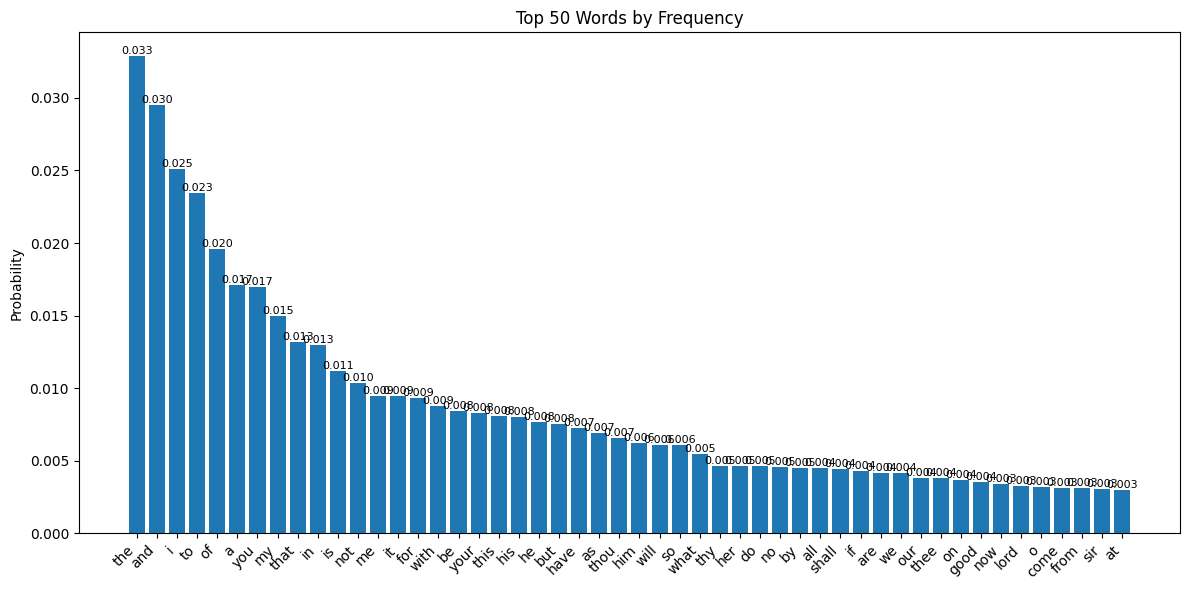

In [29]:
# Let's take a look 📊
from jamcoders.models import visualize_model
visualize_model(shake_model, top_n=50)

### Generating from the Model 💬

In [30]:
from jamcoders.random import sample_from_dict

In [31]:
text = ""
for i in range(5):
    text += " " + sample_from_dict(shake_model)
print(text)

 mathematics to me woman tis


## Another Unigram model

Let's load a model built from 1 trillion words collected from the internet

In [32]:
from jamcoders.models import tril_model

Loading Norvig unigrams...
Loaded 332,744 words


In [33]:
text = ""
for i in range(5):
    text += " " + sample_from_dict(tril_model)
print(text)

 be it technology deemed product


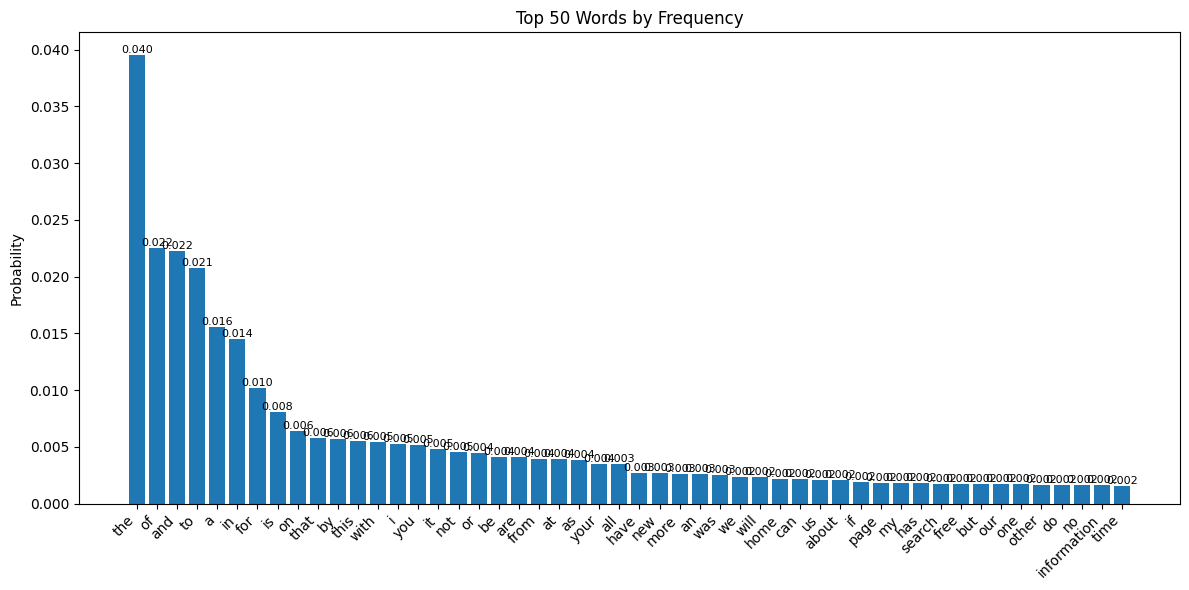

In [34]:
from jamcoders.models import visualize_model
visualize_model(tril_model, top_n=50)

## Unigram models: Wrong but useful

A Unigram model simply counts words in a dataset. 
- In what way are they useful?
- Why does that result in such weird sentences?

Our Unigram model treats each word independently:
- But in real language, words depend on what came before!
- After 'the', we're more likely to see 'cat' than another 'the'.
- This is still a Language Model! It _is_ useful (e.g., spell checkers, search engines), but it's not good for generating sentences.

# Context matters!

Here's an idea for a model that takes context into account:

- To fill in a blank
> The cat sat on the _____
- Search for the context `The cat sat on the` throughout the dataset
- Count how many times `mat`, `chair`, `roof`, ... appear next
- Compute a Probability by dividing by the number of contexts
- Then sample from these Probabilities

Is this a good model? Is it practical?

Solution: Keep _some_ context, but not all of it!

## Bigram Models

A bigram model predicts the next word _based on the previous word_

> Bi = Twice (Latin).

> Gram = Something written (Greek)

In [35]:
print(len(shake))

816140


In [36]:
# Build bigram counts from Shakespeare
# Step 1: Count how often each context word appears.
# Step 2: Count each next_word for each context.
# Step 3: Turn those counts into probabilities of next_word given a context.

In [37]:
from jamcoders.datasets import shake_words

In [38]:
# Count unigrams and bigrams
u_counts = {}
b_counts = {}

for sent in shake_words:
    for i in range(len(sent) - 1):
        context = sent[i]
        next_word = sent[i + 1]
        if sent[i] not in u_counts:
            u_counts[context] = 0
            b_counts[context] = {}
        u_counts[context] += 1
        if next_word not in b_counts[context]:
            b_counts[context][next_word] = 0
        b_counts[context][next_word] += 1
        
# Normalize (convert) bigrams into probabilities
bigram_model = {}
for context in b_counts:
    bigram_model[context] = {}
    for next_word in b_counts[context]:
        count = b_counts[context][next_word]
        bigram_model[context][next_word] = count / u_counts[context]

### Generating with Bigrams

In [39]:
from jamcoders.random import sample_from_dict
next_word = sample_from_dict(bigram_model["of"])
print(next_word)

launcelot


In [40]:
from jamcoders.random import sample_from_dict

def generate_from_bigram_model(model, start_word, length):
    context = [start_word]
    for i in range(length):
        cur_word = context[-1]
        if cur_word not in model:
            # Nothing ever followed this word in Shakespeare, so stop here.
            break
        next_word = sample_from_dict(model[cur_word])
        context.append(next_word)
    return ' '.join(context)

In [41]:
text = generate_from_bigram_model(bigram_model, "shall", 10)
print(text)

shall get you walk alone let copulation of anything now forsake


In [42]:
from jamcoders.random import sample_from_dict

def recursive_gen(model, context, length):
    if length == 0:
        return context
    cur_word = context[-1]
    next_word = sample_from_dict(model[cur_word])
    return recursive_gen(model, context + [next_word], length - 1)

### Generating poems 📜

In [43]:
verse_starts = ['shall', 'oh', 'for', 'alas']
for start in verse_starts:
    print(generate_from_bigram_model(bigram_model, start, 5))

shall never stir my master let
oh ho are born it with
for because she sings his heart's
alas good sir should be born


## MORE context: N-gram Models

What if we generated each word based on the previous _two_ words? _Three_ words? _Four_ words?

In [44]:
from jamcoders.models import load_pretrained_ngram

# Load different n-gram models
trigram_model = load_pretrained_ngram(3)
fourgram_model = load_pretrained_ngram(4)

### Comparing Different Context Lengths

In [45]:
from jamcoders.models import generate_from_ngram_model
unigram_model = shake_model # Remember? We built it earlier!

prefix = "shall"
length = 15

print("Unigram (no context):")
print(generate_from_ngram_model(unigram_model, prefix, length))
print("\nBigram (1 word context):")
print(generate_from_ngram_model(bigram_model, prefix, length))
print("\nTrigram (2 word context):")
print(generate_from_ngram_model(trigram_model, prefix, length))
print("\nFourgram (3 word context):")
print(generate_from_ngram_model(fourgram_model, prefix, length))

Unigram (no context):
shall before have out he hath and royally before to all and which music will as

Bigram (1 word context):
shall wipe away i left to climb is a beggar in good countrymen o ratcliff thyself

Trigram (2 word context):
shall i hear some

Fourgram (3 word context):
shall we go see the love the look of such a spirit and well you do


### Observe:
- Generally, more context → more coherent text
- But with too much context, the model can only repeat lines it has already seen
- Modern language models use more sophisticated ideas, building on this approach!